In [1]:
!python3.14 -m pip install yfinance pandas matplotlib statsmodels --quiet

/usr/lib/python3/dist-packages/pip/_vendor/pyparsing/core.py:5596: SyntaxWarning: 'return' in a 'finally' block
  return self.__class__.__name__ + ": " + retString


In [23]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import pandas as pd

comp1 = "V"
comp2 = "MA"
# Tickers boursiers des entreprises
# TTE  (TotalEnergies sur Euronext Paris)
# SHEL (Shell sur Euronext Amsterdam)
tickers = [comp1, comp2]

data = yf.download(tickers, start="2021-01-01", end="2026-01-01")
print("Données téléchargées.")

data[:5]

[*********************100%***********************]  2 of 2 completed

Données téléchargées.


Price            Close                    High                     Low  \
Ticker              MA           V          MA           V          MA   
Date                                                                     
2021-01-04  340.009338  208.751587  346.432471  211.138585  336.014231   
2021-01-05  336.072357  205.636017  341.470087  209.422623  334.157019   
2021-01-06  336.198151  203.824219  342.466509  207.227363  333.305821   
2021-01-07  338.861664  204.964996  341.292768  206.316670  337.428209   
2021-01-08  342.726166  206.537125  343.820647  207.179406  338.503214   

Price                         Open               Volume            
Ticker               V          MA           V       MA         V  
Date                                                               
2021-01-04  205.377215  346.306713  211.138585  4638400  10318300  
2021-01-05  204.802012  337.407258  207.361556  2990700   6869700  
2021-01-06  203.296983  338.974434  204.955411  3966800   7206200  
2021-01-07  203.421599  337.980297  203.421599  3100200  10967900  
2021-01-08  203.948823  340.314423  205.310078  3371500   6513000

In [24]:
# On garde le prix de cloture seulement
prices = data["Close"].dropna() # cours du prix de cloture
prices.head()

Ticker,MA,V
Date,,
2021-01-04,340.009338,208.751587
2021-01-05,336.072357,205.636017
2021-01-06,336.198151,203.824219
2021-01-07,338.861664,204.964996
2021-01-08,342.726166,206.537125


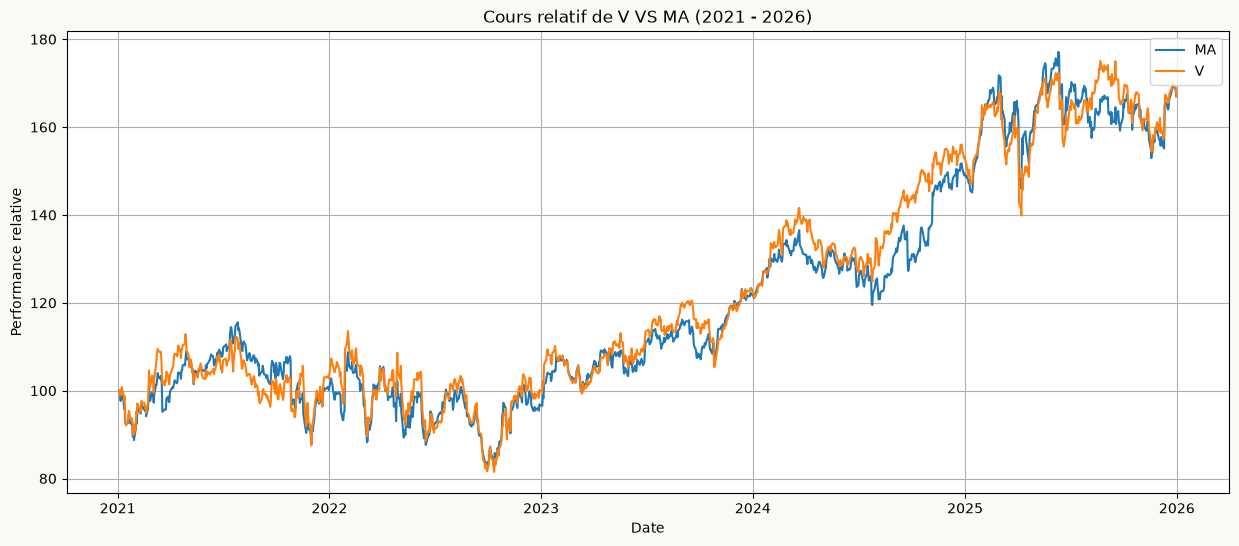

In [27]:
# Visualisation
plt.figure(figsize=(15, 6), facecolor='#fbf9f5')
normalized_prices = (prices / prices.iloc[0]) * 100 # on normalise les prix par rapport au jour 0

plt.plot(normalized_prices[comp1], label=f"{comp2}")
plt.plot(normalized_prices[comp2], label=f"{comp1}")
plt.title(f"Cours relatif de {comp1} VS {comp2} (2021 - 2026)")
plt.xlabel("Date")
plt.ylabel("Performance relative")
plt.legend()
plt.grid(True)


plt.savefig("hey")

plt.show()

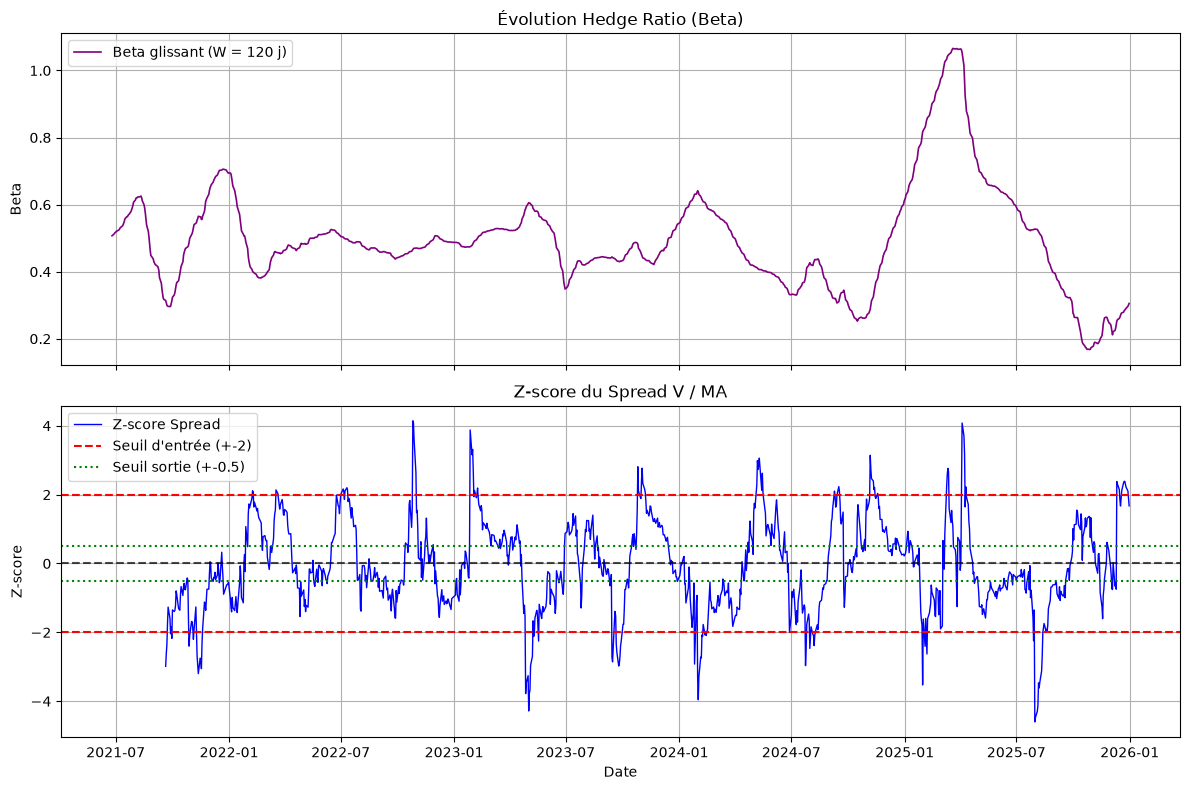

In [ ]:
W = 120         # estimation de alpha et beta (ex. 60 jours)
window_z = 60  # normalisation du Z-score

y = prices[comp1]
x = prices[comp2]
x_with_const = sm.add_constant(x)

# Régression linéaire glissante (Rolling OLS)
rols = RollingOLS(y, x_with_const, window=W)
rolling_model = rols.fit()

alpha = rolling_model.params["const"].shift(1)
beta = rolling_model.params[comp2].shift(1)

spread = y - (alpha + beta * x)

#  Z-score sur fenêtre glissante
spread_mean = spread.rolling(window=window_z).mean()
spread_std = spread.rolling(window=window_z).std()
z_score = (spread - spread_mean) / spread_std


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# hedge ratio
ax1.plot(beta, label=f"Beta glissant (W = {W} j)", color="purple", lw=1.2)
ax1.set_title("Évolution Hedge Ratio (Beta)")
ax1.set_ylabel("Beta")
ax1.grid(True)
ax1.legend(loc="upper left")

# Z-score spread
ax2.plot(z_score, label="Z-score Spread", color="blue", lw=1)
ax2.axhline(0, color="black", linestyle="--", alpha=0.7)
ax2.axhline(2.0, color="red", linestyle="--", label="Seuil d'entrée (+-2)")
ax2.axhline(-2.0, color="red", linestyle="--")
ax2.axhline(0.5, color="green", linestyle=":", label="Seuil sortie (+-0.5)")
ax2.axhline(-0.5, color="green", linestyle=":")

ax2.set_title(f"Z-score du Spread {comp1} / {comp2}")
ax2.set_xlabel("Date")
ax2.set_ylabel("Z-score")
ax2.grid(True)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [38]:
signals = pd.DataFrame(index=z_score.index)
signals["z_score"] = z_score
signals["position"] = 0  
# 0: Pas de position
# 1: Long spread
# -1: Short spread

ENTRY_THRESHOLD = 2.0
EXIT_THRESHOLD = 0.5

current_pos = 0
positions = []

for z in signals["z_score"]:
    if pd.isna(z):
        positions.append(0)
        continue

    if z >= ENTRY_THRESHOLD: current_pos = -1
    elif z <= -ENTRY_THRESHOLD: current_pos = 1
    elif abs(z) <= EXIT_THRESHOLD: current_pos = 0
    
    positions.append(current_pos) # sinon on reste dans la position qu'on avait la veille

signals["position"] = positions

In [39]:
# Nombre de jours passés en position
print(f"Nb jours sans position (0) : {(signals['position'] == 0).sum()}")
print(f"Nb jours en long (+1) : {(signals['position'] == 1).sum()}")
print(f"Nb jours en short (-1) : {(signals['position'] == -1).sum()}")

Nb jours sans position (0) : 829
Nb jours en long (+1) : 216
Nb jours en short (-1) : 210


In [40]:
# rendements journaliers
returns = pd.DataFrame(index=prices.index)
returns["TTE"] = prices[comp1].pct_change()
returns["SHEL"] = prices[comp2].pct_change()

returns["beta"] = beta

# rendement
returns["spread_return"] = (returns["TTE"] - returns["beta"] * returns["SHEL"]) / (1 + returns["beta"])

# 3. Application de la position décalée d'un jour (anti-lookahead)
signals["position_applied"] = signals["position"].shift(1).fillna(0)
returns["strategy_gross"] = signals["position_applied"] * returns["spread_return"]

# frais de transaction
# 1 changement de position = 2 ordres (un pour Total, un pour Shell)
TRANSACTION_COST = 0.0005  # 0.05% par transaction
trades = signals["position_applied"].diff().abs().fillna(0)
returns["costs"] = trades * TRANSACTION_COST

# Rendement net
returns["strategy_net"] = returns["strategy_gross"] - returns["costs"]

INITIAL_CAPITAL = 100_000
portfolio = pd.DataFrame(index=returns.index)
portfolio["equity_gross"] = INITIAL_CAPITAL * (1 + returns["strategy_gross"].fillna(0)).cumprod()
portfolio["equity_net"] = INITIAL_CAPITAL * (1 + returns["strategy_net"].fillna(0)).cumprod()

print(f"Nombre de rééquilibrages : {int(trades.sum())}")
print(f"Capital final brut : {portfolio['equity_gross'].iloc[-1]:.2f} €")
print(f"Capital final net  : {portfolio['equity_net'].iloc[-1]:.2f} €")

Nombre de rééquilibrages : 41
Capital final brut : 109344.11 €
Capital final net  : 107126.28 €


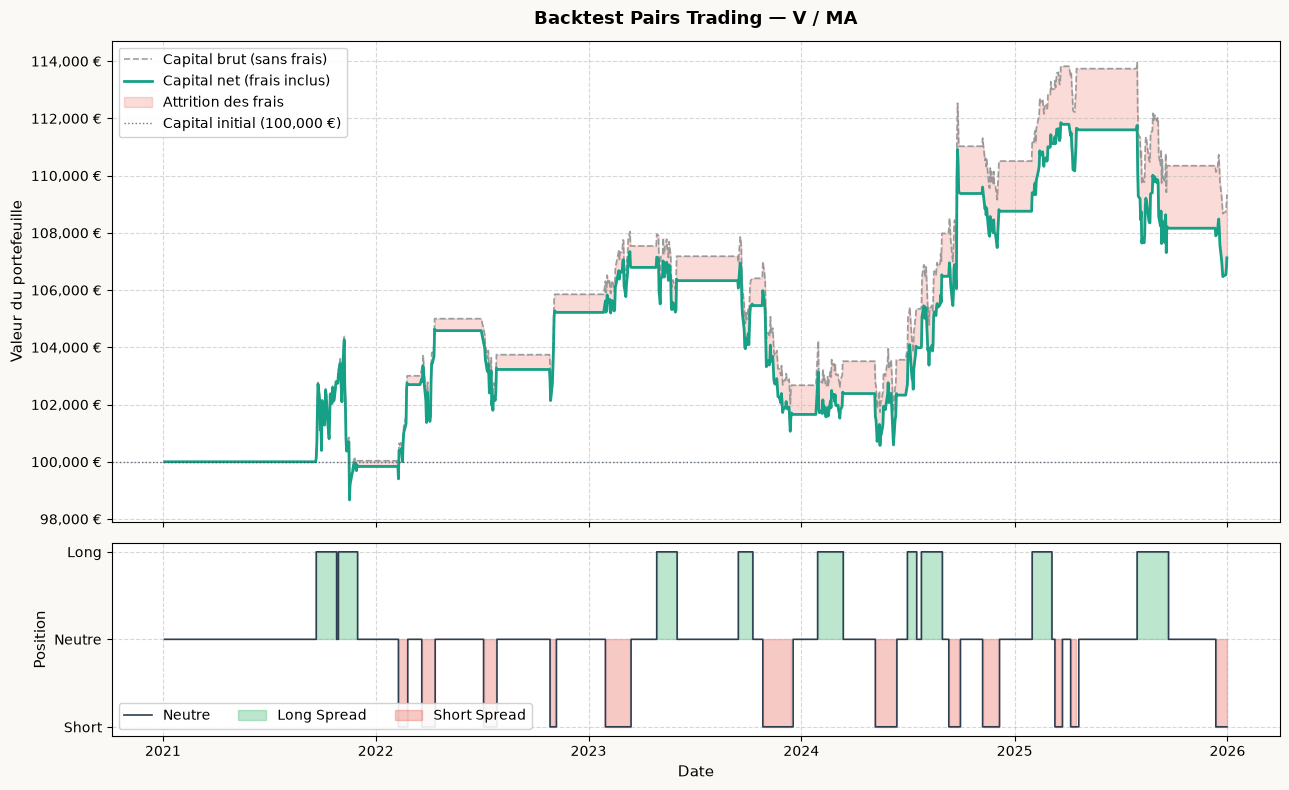

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(13, 8), facecolor='#fbf9f5', sharex=True, gridspec_kw={"height_ratios": [2.5, 1]}
)

# 1. Évolution du capital (Brut vs Net)
ax1.plot(
    portfolio["equity_gross"],
    label="Capital brut (sans frais)",
    color="#7f8c8d",
    linestyle="--",
    lw=1.2,
    alpha=0.8,
)
ax1.plot(
    portfolio["equity_net"],
    label="Capital net (frais inclus)",
    color="#16a085",
    lw=2,
)

# Remplissage entre brut et net pour visualiser l'érosion des frais
ax1.fill_between(
    portfolio.index,
    portfolio["equity_net"],
    portfolio["equity_gross"],
    color="#e74c3c",
    alpha=0.2,
    label="Attrition des frais",
)

# Ligne de référence du capital initial
ax1.axhline(
    INITIAL_CAPITAL,
    color="#2c3e50",
    linestyle=":",
    lw=1,
    alpha=0.7,
    label=f"Capital initial ({INITIAL_CAPITAL:,.0f} €)",
)

ax1.set_title(
    f"Backtest Pairs Trading — {comp1} / {comp2}",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax1.set_ylabel("Valeur du portefeuille", fontsize=11)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f} €"))
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.9)

# 2. Régimes de position et exécution des ordres
pos = signals["position_applied"]
ax2.step(pos.index, pos, where="post", color="#2c3e50", lw=1.2, label="Neutre")

# Coloration des zones d'exposition
ax2.fill_between(
    pos.index,
    0,
    pos,
    where=(pos > 0),
    color="#27ae60",
    step="post",
    alpha=0.3,
    label="Long Spread",
)
ax2.fill_between(
    pos.index,
    0,
    pos,
    where=(pos < 0),
    color="#e74c3c",
    step="post",
    alpha=0.3,
    label="Short Spread",
)

ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(["Short", "Neutre", "Long"])
ax2.set_ylabel("Position", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="lower left", frameon=True, facecolor="white", framealpha=0.9, ncol=4)

plt.tight_layout()
plt.savefig("backtest")
plt.show()

In [45]:
# période active
valid_idx = signals["position_applied"].dropna().index[W + window_z:]
active_returns = returns.loc[valid_idx, "strategy_net"]
active_equity = portfolio.loc[valid_idx, "equity_net"]

# 2. Métriques annualisées corrigées
trading_days = 252
total_return = (active_equity.iloc[-1] / active_equity.iloc[0]) - 1
n_years = len(active_returns) / trading_days
annualized_return = (1 + total_return) ** (1 / n_years) - 1

annualized_volatility = active_returns.std() * np.sqrt(trading_days)
sharpe_ratio = (active_returns.mean() * trading_days) / annualized_volatility

# 3. Drawdown calculé sur la période active
peak = active_equity.cummax()
drawdown = (active_equity - peak) / peak
max_drawdown = drawdown.min()

# 4. Taux de jours gagnants (quand on a une position ouverte)
active_trade_days = active_returns[signals.loc[valid_idx, "position_applied"] != 0]
win_rate = (active_trade_days > 0).sum() / len(active_trade_days) if len(active_trade_days) > 0 else 0

# 5. Affichage
print("=" * 45)
print("       RAPPORT D'ÉVALUATION DU RISQUE")
print("=" * 45)
print(f"Période évaluée         : {n_years:.1f} ans")
print(f"Rendement total net     : {total_return * 100:.2f} %")
print(f"Rendement annualisé     : {annualized_return * 100:.2f} %")
print(f"Volatilité annualisée   : {annualized_volatility * 100:.2f} %")
print(f"Sharpe Ratio            : {sharpe_ratio:.2f}")
print(f"Maximum Drawdown (MDD)  : {max_drawdown * 100:.2f} %")
print(f"Taux de jours gagnants  : {win_rate * 100:.2f} %")
print("=" * 45)

       RAPPORT D'ÉVALUATION DU RISQUE
Période évaluée         : 4.3 ans
Rendement total net     : 6.96 %
Rendement annualisé     : 1.59 %
Volatilité annualisée   : 5.19 %
Sharpe Ratio            : 0.34
Maximum Drawdown (MDD)  : -6.31 %
Taux de jours gagnants  : 52.47 %
